# COMP9061 Practical Machine Learning - Project 2

Thakur, N. (2024). Mpox Instagram Dataset: Sentiment and Hate Analysis. Kaggle. Retrieved from https://www.kaggle.com/datasets/thakurnirmalya/mpox-instagram-dataset-sentiment-and-hate-analysis

### Package Imports

In [23]:
!pip install --upgrade pip

%pip install nltk
%pip install openpyxl
%pip install wordcloud
%pip install pillow

# General data handling

import nltk
import pandas as pd
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 200)
import numpy as np

# Drawing plots
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# Machine learning with scikit-learn
import sklearn
import sklearn.impute
import sklearn.model_selection
import sklearn.metrics
import sklearn.tree

# System packages for saving Python objects
import os
import pickle

# Text preprocessing
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joker\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\joker\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\joker\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Load Data

To support data exploration and manipulation it is easiest to load
datasets as **Pandas DataFrames**. Here, we will load
**Dataset.xlsx**. This dataset contains Instagram posts labeled with sentiment.

Step 1: Load the data from an Excel file to a Pandas DataFrame and
examine it.


In [2]:
# Load the dataset into a DataFrame
df = pd.read_excel('Dataset.xlsx')

# Display the first few rows of the dataframe
print(df.head(8))

# Display general info about the dataframe 
print(df.info())

# Display descriptive statistics for numeric columns
print(df.describe())

       Post ID  \
0  CgXDOaQDvGm   
1  CgXpRmMIdzG   
2  CgXMyIjP34S   
3  CgXaFGDsevq   
4  CgX3rATJTXd   
5  CgXGNrmLwoL   
6  CgXOxMmOLo_   
7  CgXTqcjOQD-   

                                                                                                                                                                                          Post description  \
0  “I have decided that the global #monkeypox outbreak represents a public health emergency of international concern.”\n-WHO Director-General @drtedros, based on the International Health Regulations ...   
1  In light of the evolving monkeypox outbreak with over 16,000 reported cases from 75 countries and territories, I reconvened the emergency committee. Based on the International Health Regulations c...   
2  #LinkInBio | The World Health Organization said the expanding monkeypox outbreak in more than 70 countries is an "extraordinary" situation that now qualifies as a global emergency, a declaration t...   
3            

Step 2: Examine the distribution of the target feature.


In [3]:
# Display the distribution of the target feature (Sentiment)
sentiment_distribution = df['Sentiment'].value_counts()

# Print the sentiment distribution
print(sentiment_distribution)

Sentiment
neutral     30446
fear        16803
joy          5223
sadness      3572
anger        1617
surprise     1545
disgust       921
Name: count, dtype: int64


### Prepare Data for Modelling

There are two basic jobs that we need to do to prepare datasets for
modelling using machine learning:

-   Separate descriptive features into two sets, one for descriptive
    features and one for the target feature.
-   Divide the data into two samples, one for training the model and one
    for evaluating it.

#### Text Preprocessing

Step 3: Separate Features

sklearn expects datasets to be contained in two sets: one for
descriptive features (typically called X) and one for the target feature
(typically called y). Here you need to extract the descriptive features
for X and the target feature for y.


In [4]:
# Define a custom transformer for text preprocessing
from sklearn.tree import DecisionTreeClassifier

class TextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.apply(self._preprocess_text)

    def _preprocess_text(self, text):
        text = text.lower()
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = ' '.join([word for word in text.split() if word not in self.stop_words])
        tokens = word_tokenize(text)
        tokens = [self.lemmatizer.lemmatize(word) for word in tokens]
        return ' '.join(tokens)

pipeline = Pipeline([
    ('preprocessor', TextPreprocessor()),
    ('vectorizer', CountVectorizer()),
    ('classifier', sklearn.tree.DecisionTreeClassifier(criterion='entropy'))
])


# Set 'Post ID' as the index and drop 'Sentiment' to get the descriptive features (X)
X = df['Translated Post Description']
y = df['Sentiment']

Step 4: Examine the `X` and `y` DataFrames.

In [5]:
print(X.shape)
print(X.head(8))

# Examine y
print(y.shape)
print(y.head(8))

(60127,)
0    “I have decided that the global #monkeypox outbreak represents a public health emergency of international concern.”\n-WHO Director-General @drtedros, based on the International Health Regulations ...
1    In light of the evolving monkeypox outbreak with over 16,000 reported cases from 75 countries and territories, I reconvened the emergency committee. Based on the International Health Regulations c...
2    #LinkInBio | The World Health Organization said the expanding monkeypox outbreak in more than 70 countries is an "extraordinary" situation that now qualifies as a global emergency, a declaration t...
3                                              If you've been hearing about monkeypox and want to learn more, scroll through to find honest, accurate information and resources.\n\n#monkeypox #publichealth
4                                                                                                    Our horrific experience with MONKEYPOX…\n\n#monkeypox #monkeypoxstory 

#### Partition Data

When building machine learning models it is very common to divide a
dataset into **training**, **validation** and **test** partitions. These
partitions are used for different roles in modelling. The
**train_test_split** function from **sklearn** provides easy
functionality to do this. 

Step 5: Create a **training set** and a **validation set**.


In [6]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    df['Translated Post Description'], 
    df['Sentiment'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['Sentiment']
)

# Check the shapes of the resulting datasets
print("Training set (X_train, y_train) shape:", X_train.shape, y_train.shape)
print("Validation set (X_val, y_val) shape:", X_val.shape, y_val.shape)

Training set (X_train, y_train) shape: (48101,) (48101,)
Validation set (X_val, y_val) shape: (12026,) (12026,)


Step 6: Examine the partitions created.


In [7]:
print(X_train.head())
print(X_val.head())
print(y_train.head(8))
print(y_val.head(8))

54058         MonkeyPox is making headlines for causing rash and flu-like symptoms. Here's how to identify it.\n\n#monkeypox #monkeypoxvirus #monkeypoxawareness #monkeypoxoutbreak #precautions #medicineplanet
3833     The country&#39;s first confirmed case of monkeypox has recovered. Kollam resident (35) who was treated at Thiruvananthapuram Medical College Hospital has recovered from the disease. Health Minist...
4275     - ALERT - Four suspected cases of monkeypox are being investigated in Alagoas. According to the press office of the Dr. Helvio Auto Teaching Hospital (HEHA), the hospital received four patients wi...
8737     My uncle #SharoneReeseCook .. very gifted #eyesontheprize About to blossom #Growth #Knowyourworthchallenge #EarlyBirdShow🌞 #WisdomfromonHigh @DJMOTORCITY spiritual speaking 🔊 About to blossom #Gro...
4010     #Monkeypox usually starts with fever, malaise, headache, and lymphadenopathy and all these symptoms appear four days prior to skin lesions, rashes and othe

### Modeling: Simple Decision Tree 

To train a classification model **sklearn** uses a two-step process:

1.  Create the model object with hyperparameters
2.  Fit the model to the data (using the **fit** function).

In this first part we will build a decision tree using the
**DecisionTreeClassifier** object from **sklearn**.

Step 7: Creating a simple decision tree using the '*entropy*'
splitting criterion.


In [8]:
pipeline.fit(X_train, y_train)
print(pipeline)

Pipeline(steps=[('preprocessor',
                 <__main__.TextPreprocessor object at 0x00000187CEAEA950>),
                ('vectorizer', CountVectorizer()),
                ('classifier', DecisionTreeClassifier(criterion='entropy'))])


Step 8: Print the decision tree in a nice text format

a) using the sklearn **export_text** function. The key parameters
passed to **export_text** are:

-   **decisiontree**: The tree to be plotted.
-   **feature_names** = None: A list of the names of the features used
    in the tree.

In [9]:
from sklearn.tree import export_text
tree_text = export_text(pipeline.named_steps['classifier'], 
                        feature_names=pipeline.named_steps['vectorizer'].get_feature_names_out())
print(tree_text)

|--- emergency <= 0.50
|   |--- radio <= 0.50
|   |   |--- symptom <= 0.50
|   |   |   |--- case <= 0.50
|   |   |   |   |--- wow <= 0.50
|   |   |   |   |   |--- monkeypox <= 1.50
|   |   |   |   |   |   |--- americafirst <= 0.50
|   |   |   |   |   |   |   |--- wealth <= 0.50
|   |   |   |   |   |   |   |   |--- happy <= 0.50
|   |   |   |   |   |   |   |   |   |--- risk <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- free <= 2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 941
|   |   |   |   |   |   |   |   |   |   |--- free >  2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |--- risk >  0.50
|   |   |   |   |   |   |   |   |   |   |--- celebrate <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 59
|   |   |   |   |   |   |   |   |   |   |--- celebrate >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: joy
|   |   |   |   |   |   | 

b) the **plot_tree** method from the **DecisionTreeClassifier** object in
**sklearn**. The key parameters passed to **plot_tree** are:

-   **decisiontree**: The tree to be plotted.
-   **feature_names** = None: A list of the names of the features used
    in the tree.
-   **class_names** = None: Names of each of the target classes in
    ascending numerical order.
-   **filled** = False: Whether or not to colour the tree based on the
    target distribution at each node.

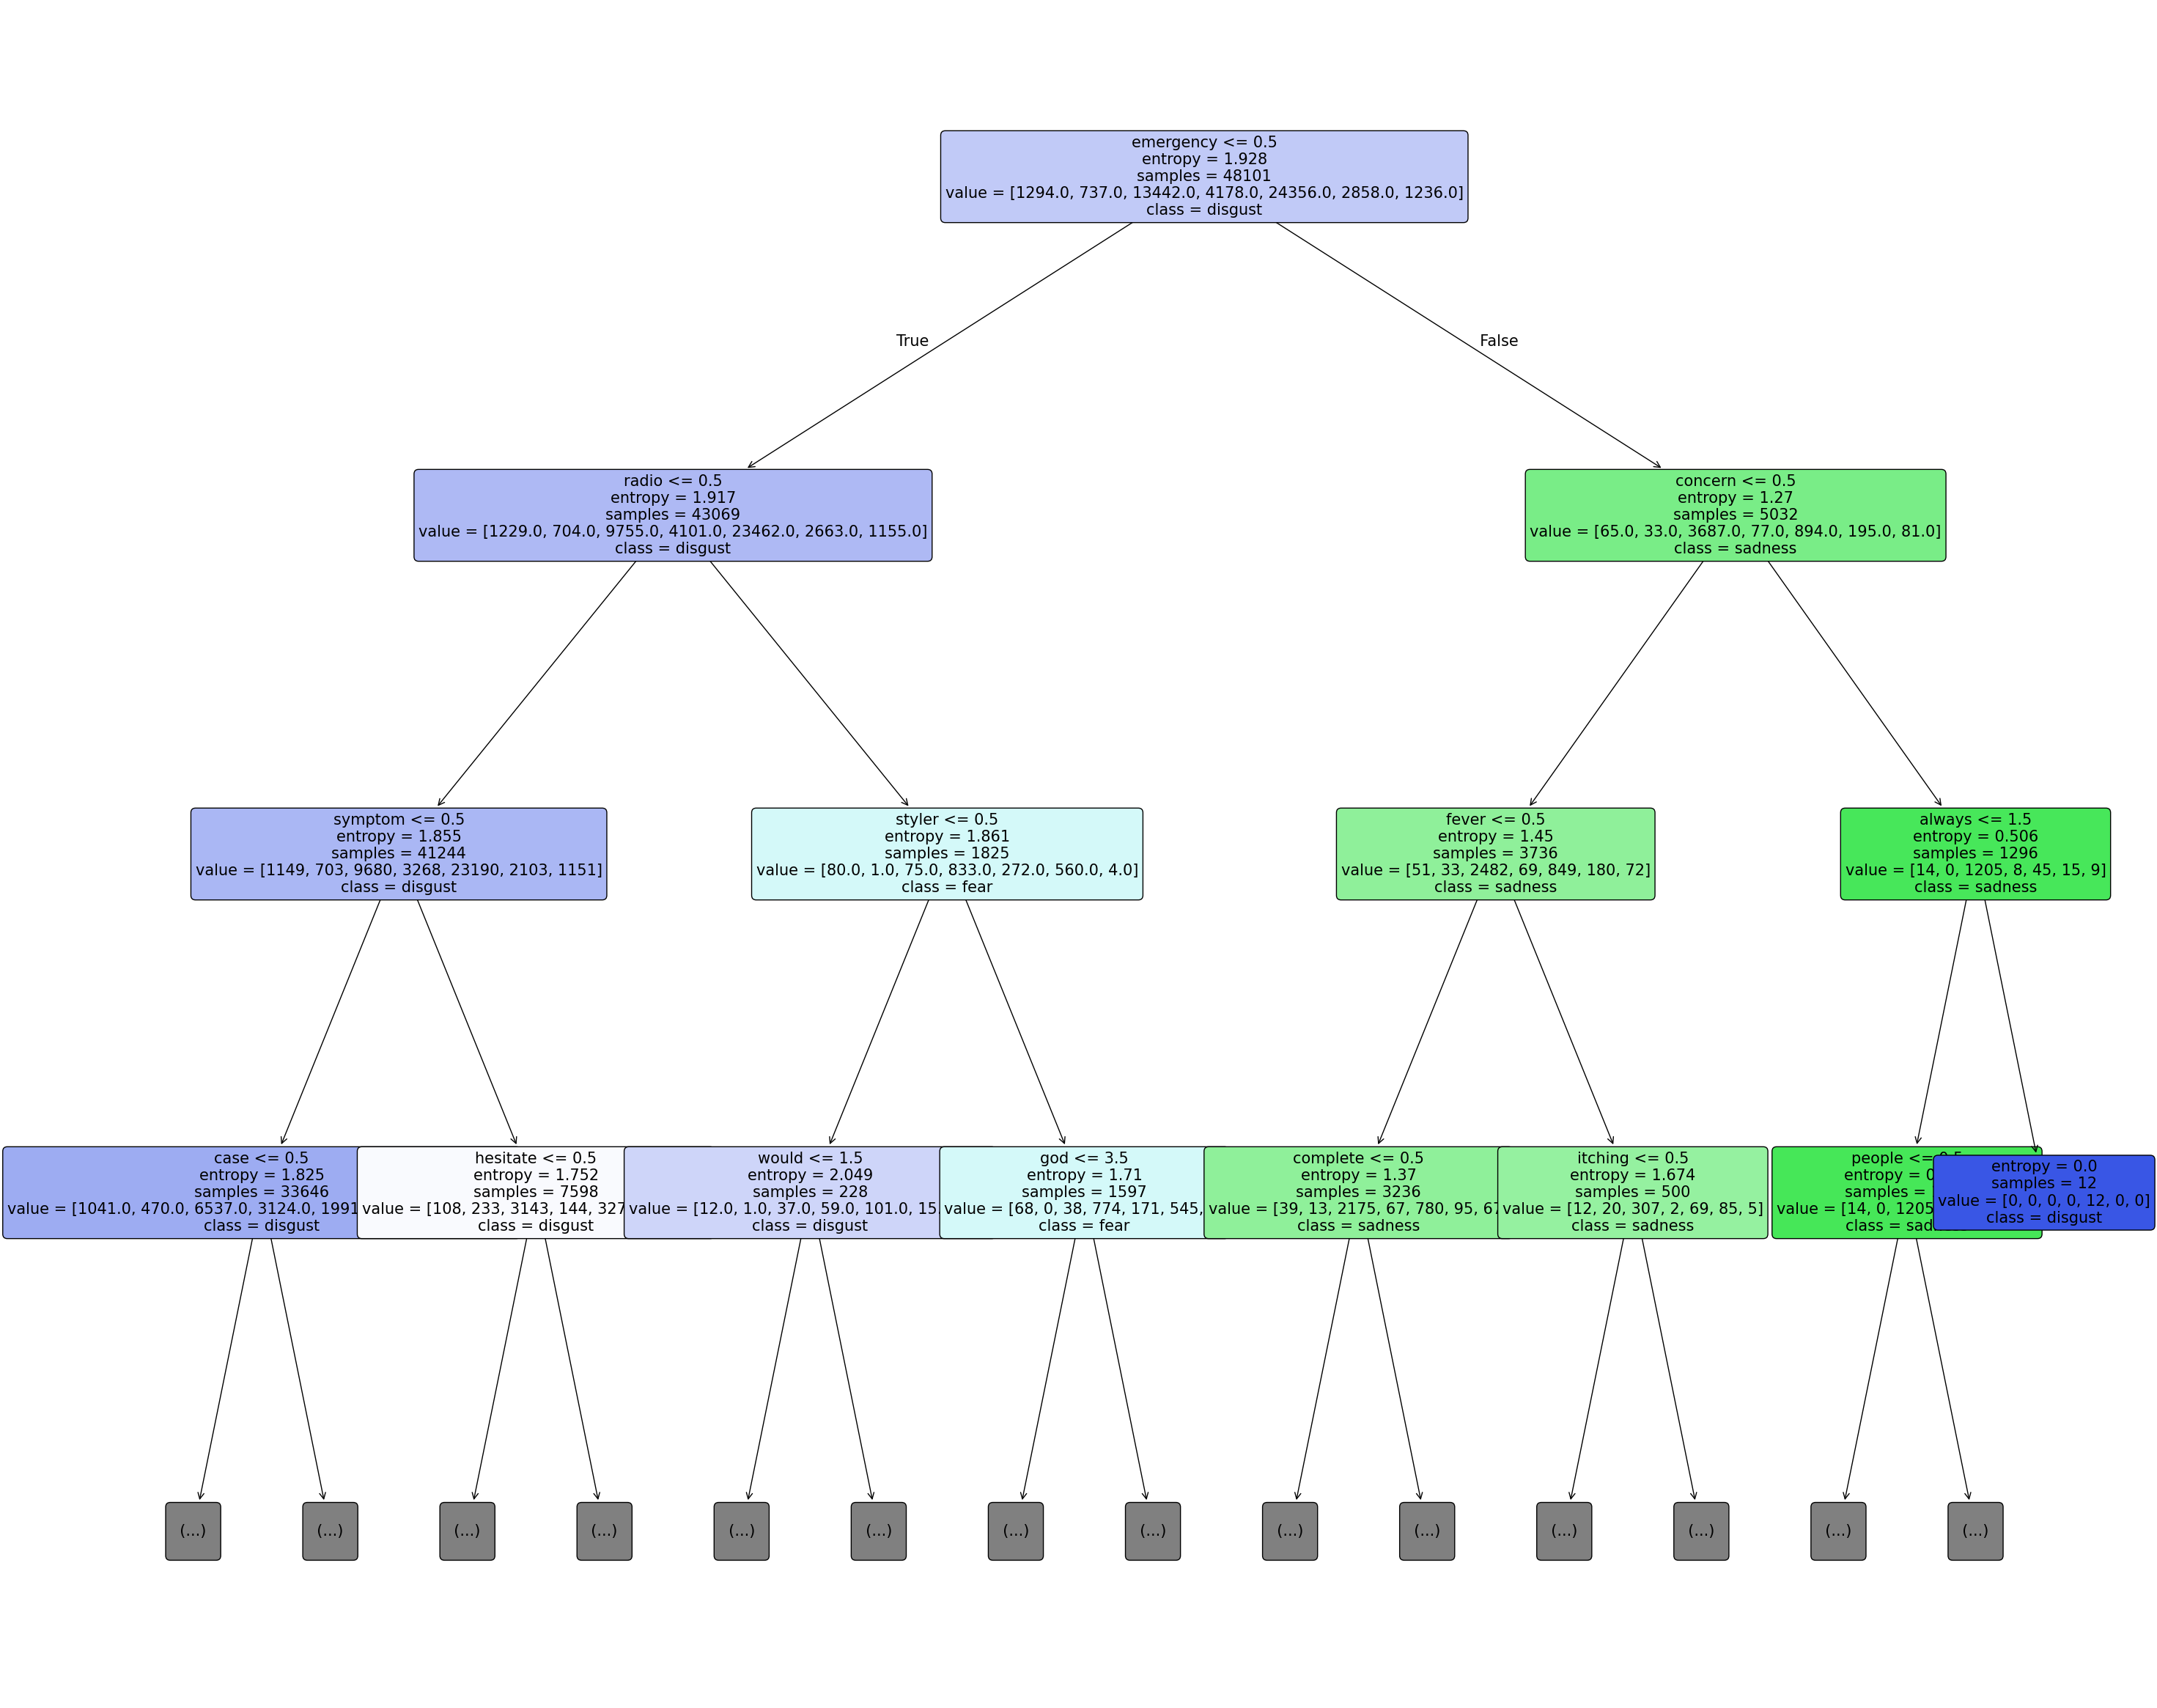

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the decision tree
plt.figure(figsize=(35,30))
plot_tree(pipeline.named_steps['classifier'],
          feature_names=pipeline.named_steps['vectorizer'].get_feature_names_out(),
          class_names=y_train.unique().astype(str),
          filled=True, 
          rounded=True,
          fontsize=15,
          max_depth=3)

# Display the plot
plt.show()

### Evaluating Model Performance

To assess the performance of a trained model, we typically use it to make
predictions on a dataset for which we know the correct target values.

Step 9: Use the **predict** method to make predictions.

In [11]:
# Making predictions using the trained DecisionTreeClassifier model
y_pred = pipeline.predict(X_val)

# This gives back a list of predictions, one for each row in the **X**
# DataFrame.

# Display the predictions
print(y_pred)

['joy' 'neutral' 'fear' ... 'fear' 'neutral' 'sadness']


Step 10: Using the **accuracy_score** method to calculate the
performance measure of your model on the validation dataset.

In [12]:
from sklearn.metrics import accuracy_score

# Calculate accuracy on the validation dataset
accuracy = accuracy_score(y_val, y_pred)

# Display the accuracy
print(f'Accuracy: {accuracy}')

Accuracy: 0.689173457508731


### Building Alternative Trees

Step 11: Create another decision tree this time limiting its depth
to 2 using the **max_depth** parameter and print the new decision tree.

In [13]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Create a decision tree with max_depth=2
tree_clf_2 = DecisionTreeClassifier(max_depth=2, random_state=42)

# Update the pipeline with the new decision tree
pipeline_2 = Pipeline([
    ('preprocessor', TextPreprocessor()),
    ('vectorizer', CountVectorizer()),  
    ('classifier', tree_clf_2)
])

# Fit the tree on the training data
pipeline_2.fit(X_train, y_train)

# Print the decision tree rules
tree_rules_2 = export_text(pipeline_2.named_steps['classifier'], feature_names=pipeline_2.named_steps['vectorizer'].get_feature_names_out())
print(tree_rules_2)

|--- emergency <= 0.50
|   |--- cafe <= 0.50
|   |   |--- class: neutral
|   |--- cafe >  0.50
|   |   |--- class: joy
|--- emergency >  0.50
|   |--- concern <= 0.50
|   |   |--- class: fear
|   |--- concern >  0.50
|   |   |--- class: fear



Step 12: Assess the performance of the decision tree on the
**validation set**

In [14]:
from sklearn.metrics import accuracy_score

# Make predictions on the validation set using the decision tree with max depth 2
y_pred_2 = pipeline_2.predict(X_val)

# Calculate accuracy of the model on the validation set
accuracy_2 = accuracy_score(y_val, y_pred_2)

# Print the accuracy
print(f"Accuracy of decision tree with max depth 2: {accuracy_2}")

Accuracy of decision tree with max depth 2: 0.5769998336936637


### Additional Algorithms

Let's try other algorithms to improve the model's accuracy.

#### Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create a RandomForestClassifier object
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Update the pipeline with the new classifier
pipeline_rf = Pipeline([
    ('preprocessor', TextPreprocessor()),
    ('vectorizer', CountVectorizer()),  
    ('classifier', rf_classifier)
])

# Fit the model to the training data
pipeline_rf.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_rf = pipeline_rf.predict(X_val)

# Calculate accuracy of the model on the validation set
accuracy_rf = accuracy_score(y_val, y_pred_rf)

# Print the accuracy
print(f"Accuracy of RandomForestClassifier: {accuracy_rf}")

Accuracy of RandomForestClassifier: 0.7470480625311824


#### Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

# Create a LogisticRegression object
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)

# Update the pipeline with the new classifier
pipeline_lr = Pipeline([
    ('preprocessor', TextPreprocessor()),
    ('vectorizer', CountVectorizer()),  
    ('classifier', lr_classifier)
])

# Fit the model to the training data
pipeline_lr.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_lr = pipeline_lr.predict(X_val)

# Calculate accuracy of the model on the validation set
accuracy_lr = accuracy_score(y_val, y_pred_lr)

# Print the accuracy
print(f"Accuracy of LogisticRegression: {accuracy_lr}")

Accuracy of LogisticRegression: 0.7574422085481457


### Confusion Matrix

To evaluate the performance of the Decision Tree model, a **confusion matrix** is generated. It provides a detailed breakdown of the model's predictions compared to the actual labels. The confusion matrix helps us identify:

- True Positives (Correctly classified positive samples)
- True Negatives (Correctly classified negative samples)
- False Positives (Incorrectly classified positive samples)
- False Negatives (Incorrectly classified negative samples)

The `ConfusionMatrixDisplay` from `sklearn` is used to visualize the confusion matrix in a clear and interpretable format. We use the **Blues colormap** to enhance the visual representation.

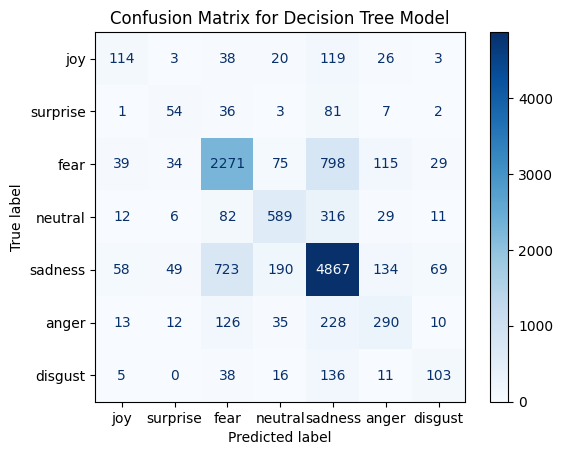

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Display the confusion matrix using sklearn's built-in function
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_val.unique())
disp.plot(cmap=plt.cm.Blues)

# Show the plot
plt.title("Confusion Matrix for Decision Tree Model")
plt.show()

## Word Cloud

The **Word Cloud** visualization highlights the most frequent words in the text data. Words with higher frequency appear larger, offering an intuitive way to identify dominant themes and keywords for each sentiment. This visualization is created for the `Translated Post Description` column grouped by each unique sentiment.

By analyzing these word clouds, we can:

1. Identify patterns in the text data for different sentiments.
2. Understand the context behind each sentiment.

The `WordCloud` library is used to generate these visualizations.

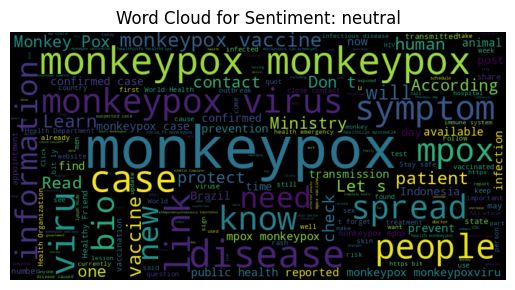

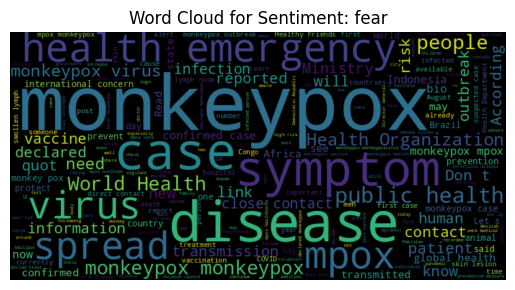

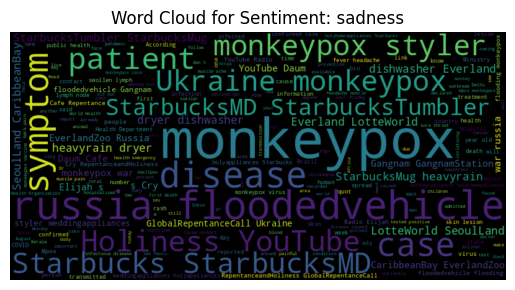

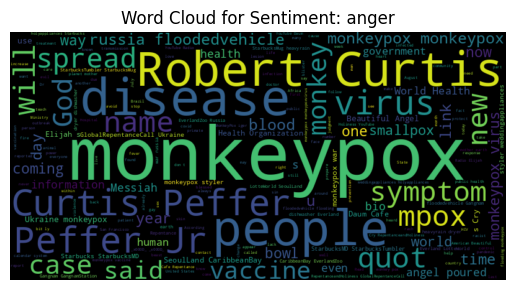

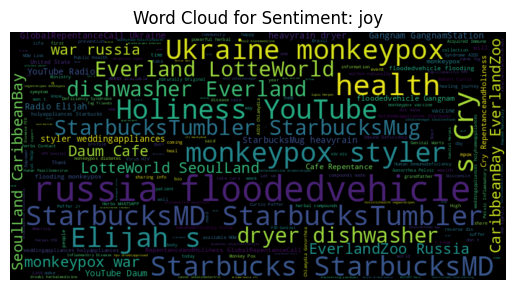

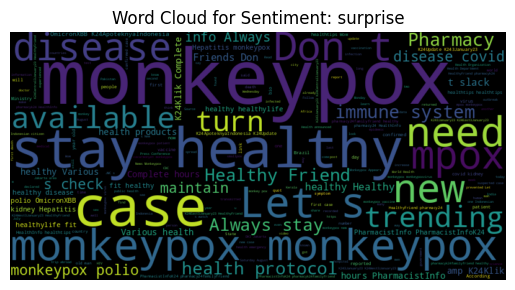

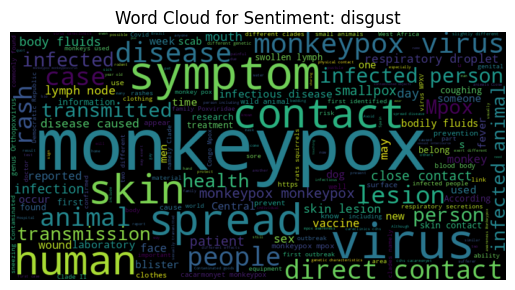

In [18]:
from wordcloud import WordCloud

# Generate a word cloud for each sentiment
for sentiment in df['Sentiment'].unique():
    text = " ".join(df[df['Sentiment'] == sentiment]['Translated Post Description'])
    wordcloud = WordCloud(width=800, height=400).generate(text)
    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for Sentiment: {sentiment}")
    plt.axis('off')
    plt.show()

## Predicted Class Distribution

The **Predicted Class Distribution** provides insights into the balance (or imbalance) of predictions made by the model. A count plot is used to show the frequency of each predicted class. This visualization helps in identifying:

1. Whether the model is overfitting or underfitting certain classes.
2. The representation of different classes in the predictions.

The `sns.countplot` function from Seaborn is used to create the bar chart, where:

- The **x-axis** represents the predicted classes.
- The **y-axis** shows the count of predictions for each class.

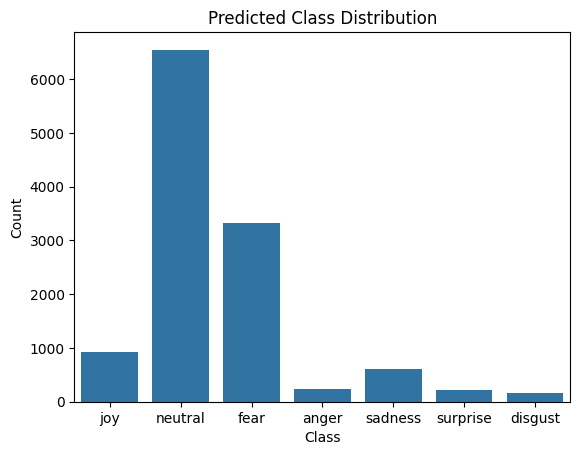

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the Predicted Class Distribution
sns.countplot(x=y_pred, hue=None)
plt.title('Predicted Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()